# Grid Search Results Analysis

This notebook consolidates the results of all grid search trials for the ProtT5 model, builds a summary CSV, and provides exploratory analysis of hyperparameters and performance metrics.

## 1. Import Required Libraries

In [2]:
import os
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from pathlib import Path

sns.set_theme(style="white", palette="muted")
%matplotlib inline

## 2. Configuration & Paths

In [3]:
# Choose model folder suffix (examples: esmc_600m, esmc_300m, ProtT5)
MODEL = "esmc_600m"
BASE_PATH = Path(f"results/grid_search_{MODEL}_AUC-APS")
# Auto-detect the single optuna trials CSV (files starting with 'optuna_trials')
optuna_candidates = list(BASE_PATH.glob("optuna_trials*.csv"))
if len(optuna_candidates) == 0:
    OPTUNA_CSV = BASE_PATH / "optuna_trials.csv"  # fallback (may not exist)
else:
    OPTUNA_CSV = optuna_candidates[0]
# Auto-detect the grid search config YAML (files starting with 'grid_search_config_search')
gs_candidates = list(BASE_PATH.glob("grid_search_config_search*.yaml"))
if len(gs_candidates) == 0:
    GS_CONFIG = BASE_PATH / "grid_search_config.yaml"  # fallback (may not exist)
else:
    GS_CONFIG = gs_candidates[0]
OUTPUT_CSV = BASE_PATH / "summary_results.csv"

In [ ]:
# Original
model_name = 'ProtT5'
BASE_PATH     = Path(f"results/grid_search_{model_name}")
# BASE_PATH     = Path(f"results/grid_search_{model_name}"_AUC-APS")
OPTUNA_CSV    = BASE_PATH / "optuna_trials_search_02-03-2026_16-54-06.csv"
GS_CONFIG     = BASE_PATH / "grid_search_config_search_02-03-2026_16-54-06.yaml"
OUTPUT_CSV    = BASE_PATH / "summary_results.csv"

In [5]:
# Hyperparameter keys to extract from each trial's config.yaml
# (must match the keys used in the search space)
HPARAM_KEYS   = ["filters", "kernel_size", "lr", "n_resnet", "p_dropout", "win_len"]

# Metrics of interest: (Dataset column value in results.csv, metric column)
METRICS_OF_INTEREST = [
    ("dev",                   "auc"),
    ("dev",                   "aps"),
    ("caid3_3/disorder_pdb",  "auc"),
    ("caid3_3/disorder_pdb",  "aps"),
    ("caid3_3/disorder_nox",  "auc"),
    ("caid3_3/disorder_nox",  "aps"),
]

# Load and display the grid search config
with open(GS_CONFIG) as f:
    gs_config = yaml.safe_load(f)

# print("=== Grid Search Config ===")
# print(yaml.dump(gs_config, default_flow_style=False))

## 3. Build Summary CSV

Iterate over every trial folder, extract hyperparameters from `config.yaml` and metrics from `results.csv`, and consolidate into a single DataFrame.

In [6]:
records = []

trial_dirs = sorted([d for d in BASE_PATH.iterdir() if d.is_dir()])
print(f"Found {len(trial_dirs)} trial folders.")

for trial_dir in trial_dirs:
    config_file  = trial_dir / "config.yaml"
    results_file = trial_dir / "results.csv"

    if not config_file.exists() or not results_file.exists():
        print(f"  Skipping {trial_dir.name}: missing files.")
        continue

    # -- Hyperparameters --
    with open(config_file) as f:
        cfg = yaml.safe_load(f)
    row = {"trial": trial_dir.name}
    for key in HPARAM_KEYS:
        row[key] = cfg.get(key, None)

    # -- Metrics --
    try:
        results_df = pd.read_csv(results_file)
        # Normalize dataset column (strip whitespace)
        results_df["Dataset"] = results_df["Dataset"].str.strip()
        for dataset, metric in METRICS_OF_INTEREST:
            col_name = f"{dataset.replace('/', '_')}_{metric}"
            mask = results_df["Dataset"] == dataset
            if mask.any():
                row[col_name] = results_df.loc[mask, metric].values[0]
            else:
                row[col_name] = None
    except Exception as e:
        print(f"  Error reading {results_file}: {e}")
        continue

    records.append(row)

summary_df = pd.DataFrame(records)
print(f"\nSummary shape: {summary_df.shape}")
summary_df.head()

Found 250 trial folders.

Summary shape: (250, 13)


,trial,filters,kernel_size,lr,n_resnet,p_dropout,win_len,dev_auc,dev_aps,caid3_3_disorder_pdb_auc,caid3_3_disorder_pdb_aps,caid3_3_disorder_nox_auc,caid3_3_disorder_nox_aps
0,trial0_filt150_ker9_resnet3_win80_lr7e-04_drop...,150,9,0.000658,3,0.2,80,0.896,0.833,0.929,0.899,0.859,0.658
1,trial100_filt50_ker3_resnet4_win45_lr4e-03_dro...,50,3,0.004135,4,0.6,45,0.913,0.853,0.950,0.925,0.851,0.611
2,trial101_filt200_ker11_resnet4_win10_lr2e-05_d...,200,11,0.000016,4,0.6,10,0.907,0.826,0.943,0.899,0.839,0.604
3,trial102_filt50_ker5_resnet3_win65_lr3e-06_dro...,50,5,0.000003,3,0.3,65,0.892,0.839,0.933,0.909,0.846,0.649
4,trial103_filt400_ker11_resnet4_win10_lr2e-04_d...,400,11,0.000242,4,0.0,10,0.908,0.831,0.944,0.912,0.846,0.625


## 4. Merge with Optuna Trials Data

The Optuna CSV contains `values_0` (dev AUC) and `values_1` (dev APS) per trial number. We extract the trial number from the folder name and merge.

In [7]:
# Extract trial number from folder name (e.g., "trial75_filt250_..." -> 75)
summary_df["trial_number"] = (
    summary_df["trial"]
    .str.extract(r"^trial(\d+)_")
    .astype(int)
)

# Load Optuna CSV
optuna_df = pd.read_csv(OPTUNA_CSV)
optuna_df = optuna_df.rename(columns={
    "number":   "trial_number",
    # "value":   "optuna_dev_auc",
    "values_0": "optuna_dev_auc",
    "values_1": "optuna_dev_aps",
})
optuna_df = optuna_df[["trial_number", "optuna_dev_auc", 
                       "optuna_dev_aps", 
                       "state"]]

# Merge
summary_df = summary_df.merge(optuna_df, on="trial_number", how="left")

# Save to CSV
summary_df.to_csv(OUTPUT_CSV, index=False)
print(f"Saved summary to {OUTPUT_CSV}")
print(f"Shape: {summary_df.shape}")
summary_df.head(10)

Saved summary to results/grid_search_esmc_600m_AUC-APS/summary_results.csv
Shape: (250, 17)


,trial,filters,kernel_size,lr,n_resnet,p_dropout,win_len,dev_auc,dev_aps,caid3_3_disorder_pdb_auc,caid3_3_disorder_pdb_aps,caid3_3_disorder_nox_auc,caid3_3_disorder_nox_aps,trial_number,optuna_dev_auc,optuna_dev_aps,state
0,trial0_filt150_ker9_resnet3_win80_lr7e-04_drop...,150,9,0.000658,3,0.2,80,0.896,0.833,0.929,0.899,0.859,0.658,0,0.896,0.833,COMPLETE
1,trial100_filt50_ker3_resnet4_win45_lr4e-03_dro...,50,3,0.004135,4,0.6,45,0.913,0.853,0.950,0.925,0.851,0.611,100,0.913,0.853,COMPLETE
2,trial101_filt200_ker11_resnet4_win10_lr2e-05_d...,200,11,0.000016,4,0.6,10,0.907,0.826,0.943,0.899,0.839,0.604,101,0.907,0.826,COMPLETE
3,trial102_filt50_ker5_resnet3_win65_lr3e-06_dro...,50,5,0.000003,3,0.3,65,0.892,0.839,0.933,0.909,0.846,0.649,102,0.892,0.839,COMPLETE
4,trial103_filt400_ker11_resnet4_win10_lr2e-04_d...,400,11,0.000242,4,0.0,10,0.908,0.831,0.944,0.912,0.846,0.625,103,0.908,0.831,COMPLETE
5,trial104_filt200_ker5_resnet2_win10_lr4e-03_dr...,200,5,0.003522,2,0.6,10,0.906,0.840,0.948,0.919,0.847,0.599,104,0.906,0.840,COMPLETE
6,trial105_filt400_ker3_resnet2_win10_lr6e-06_dr...,400,3,0.000006,2,0.6,10,0.909,0.836,0.945,0.911,0.850,0.639,105,0.909,0.836,COMPLETE
7,trial106_filt50_ker7_resnet1_win100_lr1e-03_dr...,50,7,0.001057,1,0.1,100,0.883,0.820,0.921,0.894,0.841,0.653,106,0.883,0.820,COMPLETE
8,trial107_filt400_ker9_resnet1_win35_lr7e-06_dr...,400,9,0.000007,1,0.3,35,0.916,0.864,0.951,0.931,0.851,0.641,107,0.916,0.864,COMPLETE
9,trial108_filt350_ker3_resnet1_win65_lr7e-03_dr...,350,3,0.006747,1,0.0,65,0.899,0.834,0.941,0.906,0.843,0.597,108,0.899,0.834,COMPLETE


## 5. Hyperparameter Distributions

How was the search space explored? Distribution of each hyperparameter across all trials.

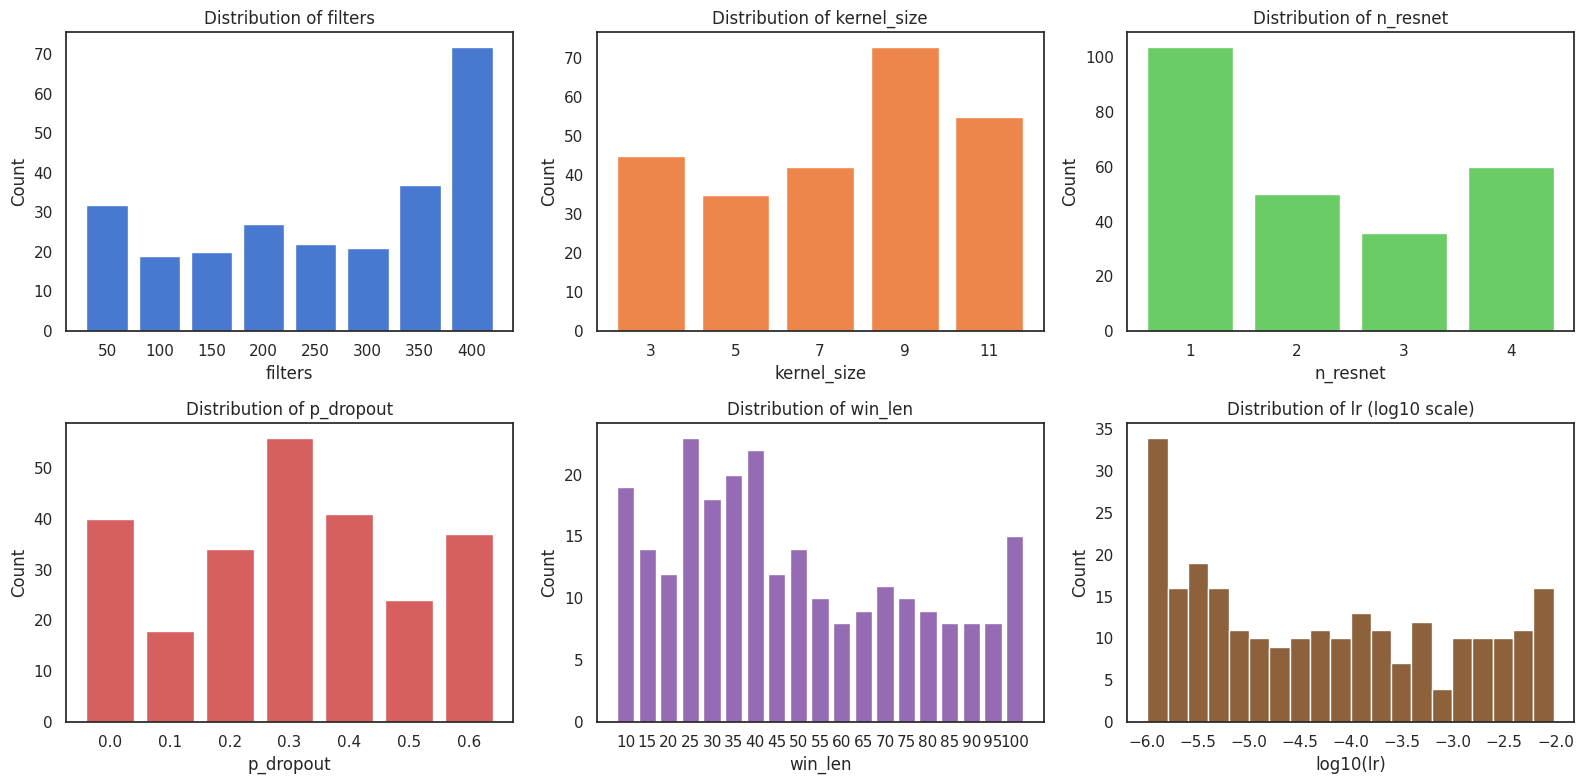

In [8]:
discrete_params = ["filters", "kernel_size", "n_resnet", "p_dropout", "win_len"]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, param in enumerate(discrete_params):
    values = summary_df[param].dropna()
    # Round floats to avoid floating-point display artifacts (e.g. 0.10000000000000001)
    if np.issubdtype(values.dtype, np.floating):
        values = values.round(2)
    counts = values.value_counts().sort_index()
    axes[i].bar(counts.index.astype(str), counts.values, color=sns.color_palette("muted")[i])
    axes[i].set_title(f"Distribution of {param}", fontsize=12)
    axes[i].set_xlabel(param)
    axes[i].set_ylabel("Count")

# lr: log-scale histogram
axes[5].hist(np.log10(summary_df["lr"].dropna()), bins=20, color=sns.color_palette("muted")[5])
axes[5].set_title("Distribution of lr (log10 scale)", fontsize=12)
axes[5].set_xlabel("log10(lr)")
axes[5].set_ylabel("Count")

plt.tight_layout()
plt.show()

## 6. Performance Metrics — Distributions & Trade-offs

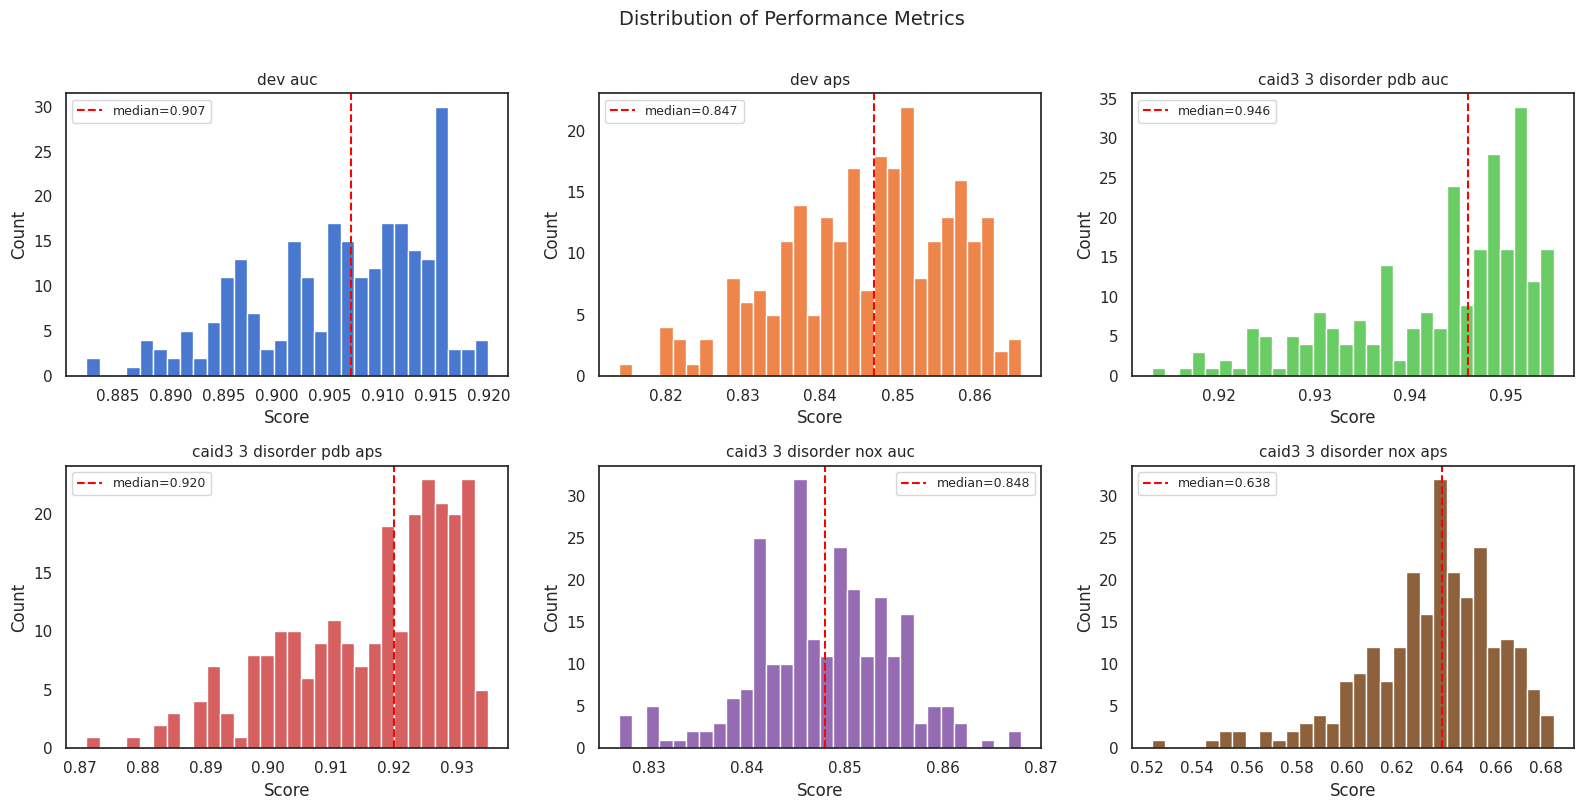

In [9]:
metric_cols = [
    "dev_auc", "dev_aps",
    "caid3_3_disorder_pdb_auc", "caid3_3_disorder_pdb_aps",
    "caid3_3_disorder_nox_auc", "caid3_3_disorder_nox_aps",
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(metric_cols):
    if col in summary_df.columns:
        axes[i].hist(summary_df[col].dropna(), bins=30, color=sns.color_palette("muted")[i], edgecolor="white")
        axes[i].axvline(summary_df[col].median(), color="red", linestyle="--", label=f"median={summary_df[col].median():.3f}")
        axes[i].set_title(col.replace("_", " "), fontsize=11)
        axes[i].set_xlabel("Score")
        axes[i].set_ylabel("Count")
        axes[i].legend(fontsize=9)
plt.suptitle("Distribution of Performance Metrics", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

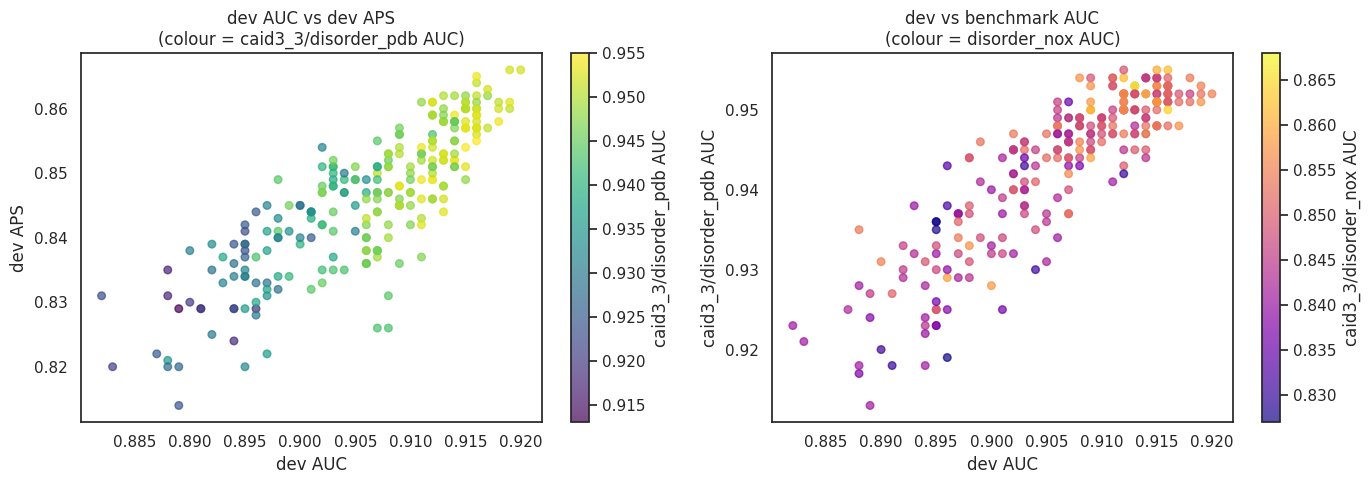

In [10]:
# Scatter: dev AUC vs dev APS, coloured by caid3_3/disorder_pdb AUC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc = axes[0].scatter(
    summary_df["dev_auc"], summary_df["dev_aps"],
    c=summary_df["caid3_3_disorder_pdb_auc"], cmap="viridis", alpha=0.7, s=30
)
plt.colorbar(sc, ax=axes[0], label="caid3_3/disorder_pdb AUC")
axes[0].set_xlabel("dev AUC")
axes[0].set_ylabel("dev APS")
axes[0].set_title("dev AUC vs dev APS\n(colour = caid3_3/disorder_pdb AUC)")

sc2 = axes[1].scatter(
    summary_df["dev_auc"], summary_df["caid3_3_disorder_pdb_auc"],
    c=summary_df["caid3_3_disorder_nox_auc"], cmap="plasma", alpha=0.7, s=30
)
plt.colorbar(sc2, ax=axes[1], label="caid3_3/disorder_nox AUC")
axes[1].set_xlabel("dev AUC")
axes[1].set_ylabel("caid3_3/disorder_pdb AUC")
axes[1].set_title("dev vs benchmark AUC\n(colour = disorder_nox AUC)")

plt.tight_layout()
plt.show()

## 7. Hyperparameter vs. Performance — Correlation & Grouped Plots

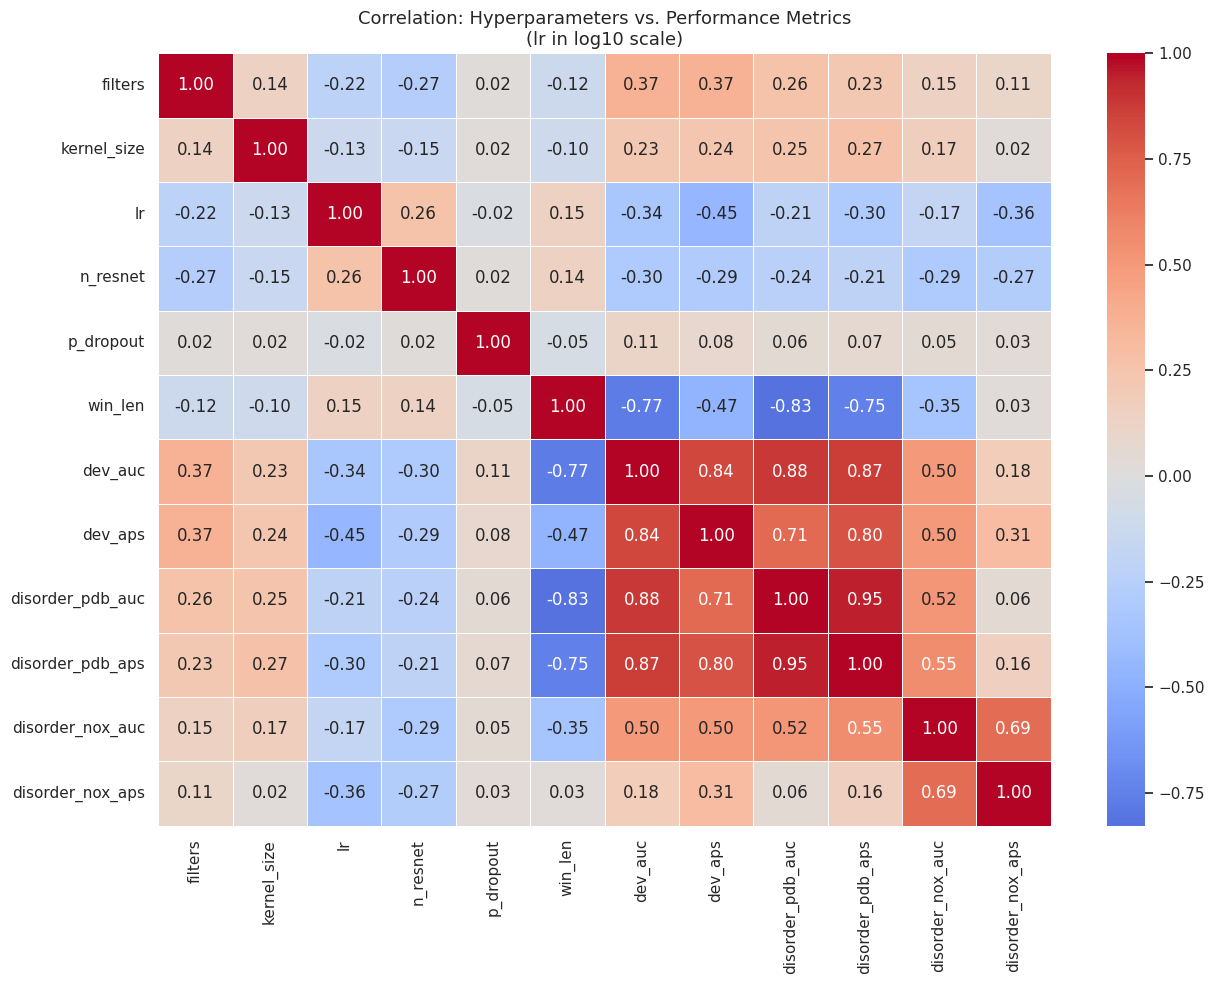

In [11]:
# Correlation heatmap: hyperparameters + metrics
analysis_cols = HPARAM_KEYS + [c for c in metric_cols if c in summary_df.columns]
corr_df = summary_df[analysis_cols].copy()
corr_df["lr"] = np.log10(corr_df["lr"])  # use log scale for lr

corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
    center=0, linewidths=0.5, ax=ax,
    xticklabels=[c.replace("caid3_3_", "") for c in corr_matrix.columns],
    yticklabels=[c.replace("caid3_3_", "") for c in corr_matrix.index],
)
ax.set_title("Correlation: Hyperparameters vs. Performance Metrics\n(lr in log10 scale)", fontsize=13)
plt.tight_layout()
plt.show()

/tmp/ipykernel_630050/1989094334.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_630050/1989094334.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_630050/1989094334.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_630050/1989094334.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_630050/1989094334.py:8: FutureWarning

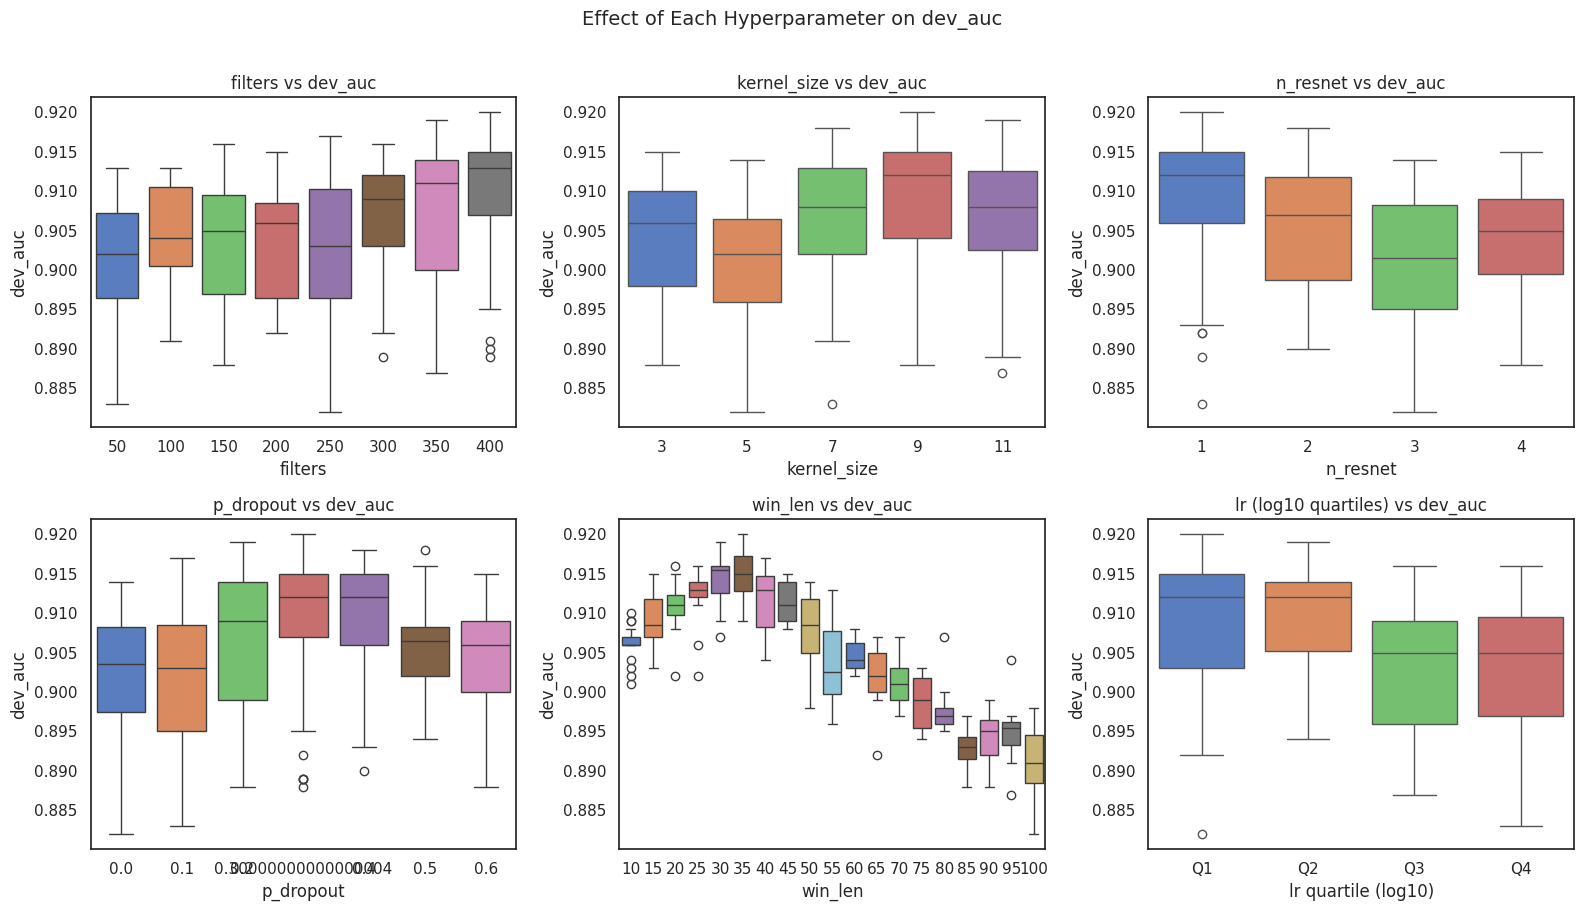

In [12]:
# Grouped boxplots: each discrete hyperparameter vs dev AUC
target_metric = "dev_auc"
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, param in enumerate(discrete_params):
    order = sorted(summary_df[param].dropna().unique())
    sns.boxplot(
        data=summary_df, x=param, y=target_metric,
        order=order, palette="muted", ax=axes[i]
    )
    axes[i].set_title(f"{param} vs {target_metric}")
    axes[i].set_xlabel(param)
    axes[i].set_ylabel(target_metric)

# lr: bin into quartiles
axes[5].cla()
summary_df["lr_bin"] = pd.qcut(np.log10(summary_df["lr"]), q=4, labels=["Q1","Q2","Q3","Q4"])
sns.boxplot(data=summary_df, x="lr_bin", y=target_metric, palette="muted", ax=axes[5])
axes[5].set_title(f"lr (log10 quartiles) vs {target_metric}")
axes[5].set_xlabel("lr quartile (log10)")

plt.suptitle(f"Effect of Each Hyperparameter on {target_metric}", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 8. Top Models Ranking

Best models ranked by dev AUC and by a combined normalized score across all metrics.

In [13]:
TOP_N = 15
display_cols = HPARAM_KEYS + [c for c in metric_cols if c in summary_df.columns]

# --- Rank by dev AUC ---
top_by_auc = (
    summary_df[["trial"] + display_cols]
    .dropna(subset=["dev_auc"])
    .sort_values("dev_auc", ascending=False)
    .head(TOP_N)
    .reset_index(drop=True)
)
print(f"=== Top {TOP_N} by dev AUC ===")
display(top_by_auc.style.background_gradient(subset=["dev_auc", "dev_aps"], cmap="YlGn"))

# --- Combined normalized score ---
score_cols = [c for c in metric_cols if c in summary_df.columns]
ranked = summary_df[["trial"] + display_cols].dropna(subset=score_cols).copy()
for col in score_cols:
    col_min, col_max = ranked[col].min(), ranked[col].max()
    ranked[f"norm_{col}"] = (ranked[col] - col_min) / (col_max - col_min + 1e-9)

norm_cols = [f"norm_{c}" for c in score_cols]
ranked["combined_score"] = ranked[norm_cols].mean(axis=1)
top_combined = ranked.sort_values("combined_score", ascending=False).head(TOP_N).reset_index(drop=True)

print(f"\n=== Top {TOP_N} by Combined Normalized Score ===")
display(top_combined[["trial"] + display_cols + ["combined_score"]]
        .style.background_gradient(subset=["combined_score"], cmap="YlGn"))

=== Top 15 by dev AUC ===


,trial,filters,kernel_size,lr,n_resnet,p_dropout,win_len,dev_auc,dev_aps,caid3_3_disorder_pdb_auc,caid3_3_disorder_pdb_aps,caid3_3_disorder_nox_auc,caid3_3_disorder_nox_aps
0,trial63_filt400_ker9_resnet1_win35_lr2e-06_drop0.30_03-03-2026_22-49-49,400,9,0.000002,1,0.300000,35,0.920000,0.866000,0.952000,0.930000,0.855000,0.650000
1,trial185_filt400_ker9_resnet1_win30_lr6e-06_drop0.20_03-03-2026_22-49-49,400,9,0.000006,1,0.200000,30,0.919000,0.860000,0.951000,0.926000,0.857000,0.652000
2,trial238_filt400_ker11_resnet1_win35_lr3e-06_drop0.30_03-03-2026_22-49-49,400,11,0.000003,1,0.300000,35,0.919000,0.861000,0.953000,0.932000,0.855000,0.669000
3,trial161_filt350_ker11_resnet1_win35_lr1e-06_drop0.30_03-03-2026_22-49-49,350,11,0.000001,1,0.300000,35,0.919000,0.866000,0.952000,0.931000,0.853000,0.648000
4,trial172_filt350_ker9_resnet2_win35_lr1e-06_drop0.40_03-03-2026_22-49-49,350,9,0.000001,2,0.400000,35,0.918000,0.860000,0.952000,0.926000,0.846000,0.620000
5,trial58_filt350_ker11_resnet1_win35_lr2e-06_drop0.40_03-03-2026_22-49-49,350,11,0.000002,1,0.400000,35,0.918000,0.861000,0.951000,0.931000,0.852000,0.648000
6,trial229_filt400_ker7_resnet1_win30_lr2e-06_drop0.50_03-03-2026_22-49-49,400,7,0.000002,1,0.500000,30,0.918000,0.858000,0.954000,0.933000,0.854000,0.657000
7,trial157_filt400_ker9_resnet1_win35_lr6e-06_drop0.10_03-03-2026_22-49-49,400,9,0.000006,1,0.100000,35,0.917000,0.862000,0.948000,0.926000,0.857000,0.647000
8,trial83_filt400_ker9_resnet2_win40_lr3e-06_drop0.40_03-03-2026_22-49-49,400,9,0.000003,2,0.400000,40,0.917000,0.857000,0.951000,0.922000,0.852000,0.657000
9,trial25_filt250_ker11_resnet1_win40_lr3e-05_drop0.30_03-03-2026_22-49-49,250,11,0.000027,1,0.300000,40,0.917000,0.863000,0.952000,0.929000,0.849000,0.640000



=== Top 15 by Combined Normalized Score ===


,trial,filters,kernel_size,lr,n_resnet,p_dropout,win_len,dev_auc,dev_aps,caid3_3_disorder_pdb_auc,caid3_3_disorder_pdb_aps,caid3_3_disorder_nox_auc,caid3_3_disorder_nox_aps,combined_score
0,trial144_filt400_ker9_resnet1_win30_lr3e-06_drop0.30_03-03-2026_22-49-49,400,9,0.000003,1,0.300000,30,0.912000,0.861000,0.954000,0.935000,0.862000,0.671000,0.908106
1,trial221_filt400_ker9_resnet1_win30_lr5e-06_drop0.40_03-03-2026_22-49-49,400,9,0.000005,1,0.400000,30,0.916000,0.860000,0.950000,0.926000,0.864000,0.679000,0.899546
2,trial238_filt400_ker11_resnet1_win35_lr3e-06_drop0.30_03-03-2026_22-49-49,400,11,0.000003,1,0.300000,35,0.919000,0.861000,0.953000,0.932000,0.855000,0.669000,0.896501
3,trial66_filt400_ker9_resnet1_win25_lr1e-06_drop0.30_03-03-2026_22-49-49,400,9,0.000001,1,0.300000,25,0.915000,0.854000,0.955000,0.935000,0.860000,0.666000,0.889490
4,trial63_filt400_ker9_resnet1_win35_lr2e-06_drop0.30_03-03-2026_22-49-49,400,9,0.000002,1,0.300000,35,0.920000,0.866000,0.952000,0.930000,0.855000,0.650000,0.888067
5,trial236_filt400_ker7_resnet2_win30_lr4e-06_drop0.40_03-03-2026_22-49-49,400,7,0.000004,2,0.400000,30,0.915000,0.860000,0.951000,0.926000,0.859000,0.683000,0.882944
6,trial31_filt300_ker9_resnet3_win45_lr4e-05_drop0.20_03-03-2026_22-49-49,300,9,0.000038,3,0.200000,45,0.914000,0.857000,0.947000,0.927000,0.867000,0.676000,0.880947
7,trial161_filt350_ker11_resnet1_win35_lr1e-06_drop0.30_03-03-2026_22-49-49,350,11,0.000001,1,0.300000,35,0.919000,0.866000,0.952000,0.931000,0.853000,0.648000,0.876085
8,trial195_filt400_ker9_resnet1_win45_lr2e-06_drop0.20_03-03-2026_22-49-49,400,9,0.000002,1,0.200000,45,0.914000,0.858000,0.952000,0.929000,0.861000,0.667000,0.875495
9,trial229_filt400_ker7_resnet1_win30_lr2e-06_drop0.50_03-03-2026_22-49-49,400,7,0.000002,1,0.500000,30,0.918000,0.858000,0.954000,0.933000,0.854000,0.657000,0.872585


## 9. Pareto Front Visualization (dev AUC vs dev APS)

Trials on the Pareto front are those where you cannot improve one metric without hurting the other.

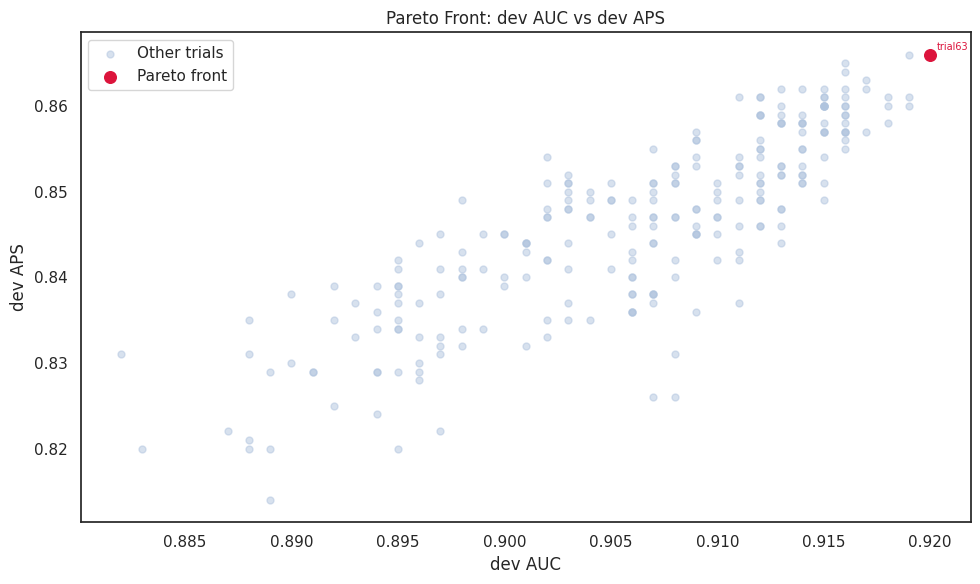

Pareto-optimal trials:


,trial,dev_auc,dev_aps,caid3_3_disorder_pdb_auc
0,trial63_filt400_ker9_resnet1_win35_lr2e-06_dro...,0.92,0.866,0.952


In [12]:
def pareto_front(df, col1, col2):
    """Return boolean mask of Pareto-optimal rows (maximizing both cols)."""
    values = df[[col1, col2]].dropna().values
    is_pareto = np.ones(len(values), dtype=bool)
    for i, v in enumerate(values):
        if is_pareto[i]:
            is_pareto[is_pareto] = np.any(values[is_pareto] > v, axis=1)
            is_pareto[i] = True
    pareto_idx = df[[col1, col2]].dropna().index[is_pareto]
    mask = df.index.isin(pareto_idx)
    return mask

plot_df = summary_df[["trial", "dev_auc", "dev_aps", "caid3_3_disorder_pdb_auc"]].dropna()
pareto_mask = pareto_front(plot_df, "dev_auc", "dev_aps")

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(
    plot_df.loc[~pareto_mask, "dev_auc"],
    plot_df.loc[~pareto_mask, "dev_aps"],
    c="lightsteelblue", alpha=0.5, s=25, label="Other trials"
)
pareto_pts = plot_df.loc[pareto_mask].sort_values("dev_auc")
ax.scatter(
    pareto_pts["dev_auc"], pareto_pts["dev_aps"],
    c="crimson", s=70, zorder=5, label="Pareto front"
)
ax.step(
    pareto_pts["dev_auc"], pareto_pts["dev_aps"],
    where="post", color="crimson", linewidth=1.5, linestyle="--"
)
for _, row in pareto_pts.iterrows():
    ax.annotate(
        row["trial"].split("_")[0],
        (row["dev_auc"], row["dev_aps"]),
        textcoords="offset points", xytext=(5, 3), fontsize=7, color="crimson"
    )
ax.set_xlabel("dev AUC")
ax.set_ylabel("dev APS")
ax.set_title("Pareto Front: dev AUC vs dev APS")
ax.legend()
plt.tight_layout()
plt.show()

print("Pareto-optimal trials:")
display(plot_df.loc[pareto_mask].sort_values("dev_auc", ascending=False).reset_index(drop=True))